# ML final project
date: 30.06.2025

last updated: 23.07.2025

---

## 🦠 Project Title: Predicting Airborne Disease Spread Using Urban Mobility and Environmental Factors

---

## 🎯 Core Objective:
Train a **spatiotemporal deep learning model** — such as a Graph Neural Network (GNN) or Transformer — to forecast the likelihood of increased disease spread in urban areas by combining:

* **Human mobility patterns**
* **Air quality and weather data**
* **Historical outbreak data**

---

## 🔍 Scientific Questions:

1. *Can mobility + air quality explain spatial clusters of disease spread better than historical cases alone?*
2. *Which environmental features (e.g., PM2.5, humidity) correlate most strongly with surges?*
3. *Can we generalize prediction models across cities or countries?*

---

## 📦 Data Sources

### 1. **Mobility Data**

[Google Community Mobility Reports (GCMR)](https://www.google.com/covid19/mobility/): % change in visits to workplaces, transit stations, etc. per country/city over time.

---

### 2. **Air Quality and Weather**

 * AQI for PM2.5: https://aqs.epa.gov/aqsweb/airdata/download_files.html; 88101 files 
 * AQI for Ozone: https://aqs.epa.gov/aqsweb/airdata/download_files.html 44201 files
 * Weather: https://archive-api.open-meteo.com/v1/archive

---

### 3. **Disease Case Data**

https://raw.githubusercontent.com/nychealth/coronavirus-data/master/trends/data-by-day.csv

--

## Model Long Short Term Memory**

 * add pin-ball loss function to predict distribution instead of scalar for covid cases (quantiles)
 * add population of city as constant in first hidden layer as bias (usually first hidden layer is random)

---

## 📚 Background Reading & Literature

* **COVID-19 Modeling with Deep Learning**:
  [“DeepCOVIDNet: An Interpretable Deep Learning Model for Predictive Surveillance” (2020)](https://arxiv.org/abs/2004.07449)
  (uses mobility and demographics for COVID-19 prediction)

* **Graph Neural Networks for Epidemiology**:
  [“EpiGNN: Epidemic Forecasting with Graph Neural Networks” (2021)](https://arxiv.org/abs/2103.13238)

* **Spatiotemporal GNNs** (survey):
  [“A Comprehensive Survey on Graph Neural Networks” (2021, Section 5)](https://arxiv.org/abs/1901.00596)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests
import pickle
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import r2_score, mean_absolute_error


# Part 1: Collect and Clean Data

In [2]:
from data_loading import *

In [101]:
# # Load all data
# df_cases = load_covid_cases()
# df_aqi = load_air_quality()
# df_mobility = load_GCMR()
# df_weather = load_weather()

# print(df_weather['date'].dtype, df_mobility['date'].dtype, df_aqi['date'].dtype, df_cases['date'].dtype)

# # Merge
# df = df_aqi.merge(df_weather, on='date', how='left')
# df = df.merge(df_mobility, on='date', how='left')
# df = df.merge(df_cases, on='date', how='left')

# df.head()


datetime64[ns] datetime64[ns] datetime64[ns] datetime64[ns]


,date,PM2.5_AQI,Ozone_AQI,temp_max,temp_min,humidity,mobility_index,covid_cases
0,2020-02-29,22.0,30.6,2.5,-4.0,45,2.750000,1
1,2020-02-29,22.0,30.6,2.5,-4.0,45,7.500000,1
2,2020-02-29,22.0,30.6,2.5,-4.0,45,7.333333,1
3,2020-02-29,22.0,30.6,2.5,-4.0,45,5.250000,1
4,2020-02-29,22.0,30.6,2.5,-4.0,45,5.750000,1


In [3]:
# with open('./df.pickle','wb') as f:
#     pickle.dump(df, f)

In [4]:
df = pickle.load(open(f'./df.pickle','rb'))

In [5]:
df

,date,PM2.5_AQI,Ozone_AQI,temp_max,temp_min,humidity,mobility_index,covid_cases
0,2020-02-29,22.00,30.6,2.5,-4.0,45,2.750000,1
1,2020-02-29,22.00,30.6,2.5,-4.0,45,7.500000,1
2,2020-02-29,22.00,30.6,2.5,-4.0,45,7.333333,1
3,2020-02-29,22.00,30.6,2.5,-4.0,45,5.250000,1
4,2020-02-29,22.00,30.6,2.5,-4.0,45,5.750000,1
...,...,...,...,...,...,...,...,...
59043,2022-10-15,51.25,38.8,19.0,7.6,73,8.666667,1029
59044,2022-10-15,51.25,38.8,19.0,7.6,73,5.333333,1029
59045,2022-10-15,51.25,38.8,19.0,7.6,73,-5.000000,1029
59046,2022-10-15,51.25,38.8,19.0,7.6,73,15.000000,1029


## Part 2: Feature engineering 
Adding lags


### Rolling window prediction setup
Train over the past 30 days and give a prediction for the 31. day. And then shift by 1 day...


Each sample in X is a 30×5 matrix (30 days × 5 features)

Each y is the COVID case count on the next (31st) day --> make it in quantiles
for that we need to add a pin-ball loss function to the model

In [6]:
def create_lagged_dataset(df, feature_cols, target_col='covid_cases', window_size=30):
    """
    Converts a time-series dataframe into samples with lag features for supervised learning.
    """
    X, y = [], []
    for i in range(len(df) - window_size):
        window = df.iloc[i:i+window_size]
        X.append(window[feature_cols].values)
        y.append(df.iloc[i + window_size][target_col])
    
    X = np.array(X)  # shape: (samples, 30, num_features)
    y = np.array(y)  # shape: (samples,)
    return X, y


In [7]:
feature_cols = ['mobility_index', 'PM2.5_AQI', 'Ozone_AQI', 'temp_max', 'temp_min', 'humidity', 'covid_cases']
X, y = create_lagged_dataset(df, feature_cols)

print("X shape:", X.shape)  # e.g., (1000, 30, 5)
print("y shape:", y.shape)  # e.g., (1000,)


X shape: (59018, 30, 7)
y shape: (59018,)


Split dataset to:
 - 70% training
 - 15% validation
 - 15% test



In [8]:
from sklearn.model_selection import train_test_split

# First split: training+validation vs test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Second split: training vs validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15/0.85, random_state=42)


In [9]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Create datasets
train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


## Part 3: Create Model
**LSTM: Long short term memory**
 - expects input as (batch_size, sequence_length, num_features)
 - output from LSTM: (batch, 30, hidden_dim)
 - output from last hidden: fc(last_hidden)	(batch,) or (batch, 1) = Scalar prediction of COVID cases (day 31)
 
 
**Add pin ball loss function for quantiles prediction**

 - underestimation is penalised more for higher quantiles:
  - Mathematically:        
  for prediction > actual:      
  loss = (1-quantile)*(prediction-actual); e.g. pred = 110, actual=100 -> loss = 1
  
  for prediction < actual:
  loss = quantile * (actual-prediction)

In [10]:
from model import *

**Improvements for v2:** 

1. Add dropout regularization to prevent overfitting: add in forward step before final layer:          
    self.lstm = nn.LSTM(..., dropout=0.2, num_layers=2)      
    self.dropout = nn.Dropout(0.3)              

2. Use learning rate scheduler: call at the end of each epoch: scheduler.step(val_loss)          
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)       

3. Use bidirectional learning       
    self.lstm = nn.LSTM(..., bidirectional=True)       
    self.fc = nn.Linear(hidden_size * 2, len(quantiles))        

4. Weight decay to avoid overfitting (L2 regularization)     
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)      

5. Add R2 (coefficient of determination) or MAE (mean absolute error) for visualisation only (in training we have pinball loss) 


**Future things to try:**

1. Add quantile crossing penalty for smoothing quantile losses        
    crossing_penalty = torch.mean(torch.relu(preds[:, 0] - preds[:, 1]) + torch.relu(preds[:, 1] - preds[:, 2]))        
    total_loss = pinball_loss + 0.1 * crossing_penalty     

2. adding additional fully conntected layers

## Part 4: Training

In [14]:
# version 2
import os
import time

force_new_training = False

checkpoint_path = "quantile_lstm_checkpoint_v2.pt"
best_model_path = "quantile_lstm_best_model_v2.pt"
start_epoch = 0
loss_over_epochs = []
val_loss_over_epochs = []
val_r2_over_epochs = []
val_mae_over_epochs = []
best_val_loss = float("inf")

model = QuantileLSTM()
quantiles = [0.1, 0.5, 0.9]
criterion = [PinballLoss(tau) for tau in quantiles]
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)       
        
patience = 10
epochs_no_improve = 0

# Optional: Load checkpoint if continuing
if os.path.exists(checkpoint_path) and force_new_training==False:
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    loss_over_epochs = checkpoint["loss_over_epochs"]
    val_loss_over_epochs = checkpoint["val_loss_over_epochs"]
    val_r2_over_epochs = checkpoint.get("val_r2_over_epochs", [])
    val_mae_over_epochs = checkpoint.get("val_mae_over_epochs", [])
    best_val_loss = min(val_loss_over_epochs)
    print(f"Resumed training from epoch {start_epoch}")

startTime = time.time()
# Training loop
for epoch in range(start_epoch, 500):
    total_loss = 0
    for xb, yb in train_loader:
        preds = model(xb)
        loss = 0
        for i in range(len(quantiles)):
            loss += criterion[i](preds[:, i], yb)
        loss /= len(quantiles)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    avg_val_loss, val_r2, val_mae = evaluate(model, val_loader, quantiles)

    # logging
    loss_over_epochs.append(avg_train_loss)
    val_loss_over_epochs.append(avg_val_loss)
    val_r2_over_epochs.append(val_r2)
    val_mae_over_epochs.append(val_mae)

    print(f"Epoch {epoch+1} | Train loss: {avg_train_loss:.4f} | Val loss: {avg_val_loss:.4f} | R2: {val_r2:.3f} | MAE: {val_mae:.3f}")

    scheduler.step(avg_val_loss)
    
    # Save checkpoint
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss_over_epochs": loss_over_epochs,
        "val_loss_over_epochs": val_loss_over_epochs,
        "val_r2_over_epochs": val_r2_over_epochs,
        "val_mae_over_epochs": val_mae_over_epochs,
    }, checkpoint_path)
    
    # Save best model based on validation loss
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"Saved new best model with val loss {best_val_loss:.4f}")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience: # when model doesnt improve anymore over 10 epochs (patience), stop
            print(f"Early stopping at epoch {epoch+1}")
            break
    if epoch%10==0:
        endtime = time.time()
        print(f'So far we are training for {(endtime-startTime)/60:.0f} minutes.')

/tmp/ipykernel_34331/1889143889.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


Resumed training from epoch 2
Epoch 3 | Train loss: 1199.5672 | Val loss: 1150.5029 | R2: -0.210 | MAE: 2296.363
Saved new best model with val loss 1150.5029
So far we are training for 1 minutes.
Epoch 4 | Train loss: 1169.1028 | Val loss: 1119.1019 | R2: -0.197 | MAE: 2233.916
Saved new best model with val loss 1119.1019
So far we are training for 2 minutes.
Epoch 5 | Train loss: 1137.6025 | Val loss: 1089.8638 | R2: -0.185 | MAE: 2176.230
Saved new best model with val loss 1089.8638
So far we are training for 4 minutes.
Epoch 6 | Train loss: 1109.7130 | Val loss: 1062.2594 | R2: -0.174 | MAE: 2122.151
Saved new best model with val loss 1062.2594
So far we are training for 5 minutes.
Epoch 7 | Train loss: 1082.7616 | Val loss: 1035.5056 | R2: -0.162 | MAE: 2068.748
Saved new best model with val loss 1035.5056
So far we are training for 6 minutes.
Epoch 8 | Train loss: 1057.0755 | Val loss: 1010.3432 | R2: -0.151 | MAE: 2018.195
Saved new best model with val loss 1010.3432
So far we ar

Epoch 54 | Train loss: 484.0612 | Val loss: 437.8076 | R2: 0.145 | MAE: 896.264
Saved new best model with val loss 437.8076
So far we are training for 75 minutes.
Epoch 55 | Train loss: 480.7054 | Val loss: 436.3180 | R2: 0.148 | MAE: 902.205
Saved new best model with val loss 436.3180
So far we are training for 76 minutes.
Epoch 56 | Train loss: 476.6927 | Val loss: 432.3190 | R2: 0.152 | MAE: 891.890
Saved new best model with val loss 432.3190
So far we are training for 77 minutes.
Epoch 57 | Train loss: 473.0021 | Val loss: 429.6868 | R2: 0.155 | MAE: 893.456
Saved new best model with val loss 429.6868
So far we are training for 79 minutes.
Epoch 58 | Train loss: 470.4546 | Val loss: 426.7271 | R2: 0.158 | MAE: 884.853
Saved new best model with val loss 426.7271
So far we are training for 80 minutes.
Epoch 59 | Train loss: 467.0943 | Val loss: 424.2235 | R2: 0.161 | MAE: 885.023
Saved new best model with val loss 424.2235
So far we are training for 81 minutes.
Epoch 60 | Train loss:

Epoch 111 | Train loss: 391.0313 | Val loss: 350.3874 | R2: 0.275 | MAE: 744.348
Epoch 112 | Train loss: 389.0399 | Val loss: 349.5415 | R2: 0.276 | MAE: 740.832
So far we are training for 158 minutes.
Epoch 113 | Train loss: 388.8510 | Val loss: 351.1506 | R2: 0.277 | MAE: 753.581
So far we are training for 160 minutes.
Epoch 114 | Train loss: 387.6561 | Val loss: 342.7156 | R2: 0.278 | MAE: 710.426
Saved new best model with val loss 342.7156
So far we are training for 161 minutes.
Epoch 115 | Train loss: 386.8067 | Val loss: 349.2978 | R2: 0.278 | MAE: 743.019
So far we are training for 162 minutes.
Epoch 116 | Train loss: 387.6934 | Val loss: 343.3551 | R2: 0.279 | MAE: 715.902
So far we are training for 164 minutes.
Epoch 117 | Train loss: 386.4190 | Val loss: 348.1284 | R2: 0.279 | MAE: 741.103
So far we are training for 165 minutes.
Epoch 118 | Train loss: 386.5764 | Val loss: 349.6334 | R2: 0.280 | MAE: 745.085
So far we are training for 166 minutes.
Epoch 119 | Train loss: 385.

## Part 5: Plotting

### Version 2
bachdrop regularization, scheduler for learning rate, bidirectional learning, patience, ...

In [15]:
# loading checkpoints
checkpoint_path = "quantile_lstm_checkpoint_v2.pt"
best_model_path = "quantile_lstm_best_model_v2.pt"

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    loss_over_epochs = checkpoint["loss_over_epochs"]
    val_loss_over_epochs = checkpoint["val_loss_over_epochs"]
    val_r2_over_epochs = checkpoint.get("val_r2_over_epochs", [])
    val_mae_over_epochs = checkpoint.get("val_mae_over_epochs", [])
    best_val_loss = min(val_loss_over_epochs)

/tmp/ipykernel_34331/3117592063.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


Text(0, 0.5, 'Loss')

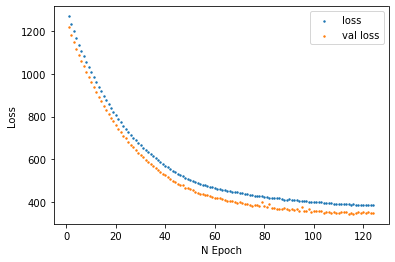

In [16]:
plt.scatter(np.linspace(1, len(loss_over_epochs),len(loss_over_epochs)),loss_over_epochs,s=2,label='loss')
plt.scatter(np.linspace(1,len(val_loss_over_epochs),len(val_loss_over_epochs)),val_loss_over_epochs,s=2,label='val loss')
plt.legend()
plt.xlabel('N Epoch')
plt.ylabel('Loss')

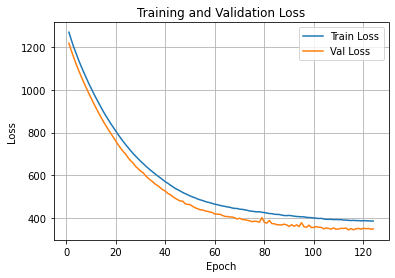

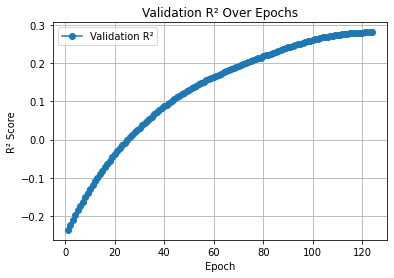

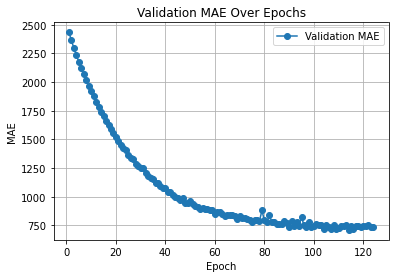

In [17]:
epochs = range(1, len(loss_over_epochs) + 1)

# Training and Validation Loss
plt.figure()
plt.plot(epochs, loss_over_epochs, label="Train Loss")
plt.plot(epochs, val_loss_over_epochs, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# R²
plt.figure()
plt.plot(range(1, len(val_r2_over_epochs) + 1), val_r2_over_epochs, marker='o', label="Validation R²")
plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.title("Validation R² Over Epochs")
plt.grid(True)
plt.legend()
plt.show()

# MAE
plt.figure()
plt.plot(range(1, len(val_mae_over_epochs) + 1), val_mae_over_epochs, marker='o', label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Validation MAE Over Epochs")
plt.grid(True)
plt.legend()
plt.show()


### Simple model

In [32]:
# loading checkpoints
checkpoint_path = "quantile_lstm_checkpoint_simple.pt"
best_model_path = "quantile_lstm_best_model_simple.pt"

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    loss_over_epochs = checkpoint["loss_over_epochs"]
    val_loss_over_epochs = checkpoint["val_loss_over_epochs"]
    val_r2_over_epochs = checkpoint.get("val_r2_over_epochs", [])
    val_mae_over_epochs = checkpoint.get("val_mae_over_epochs", [])
    best_val_loss = min(val_loss_over_epochs)

/tmp/ipykernel_19367/2806672793.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


Text(0, 0.5, 'Loss')

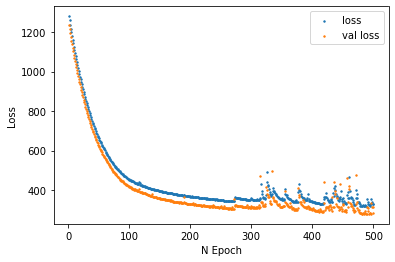

In [30]:
plt.scatter(np.linspace(1, len(loss_over_epochs),len(loss_over_epochs)),loss_over_epochs,s=2,label='loss')
plt.scatter(np.linspace(1,len(val_loss_over_epochs),len(val_loss_over_epochs)),val_loss_over_epochs,s=2,label='val loss')
plt.legend()
plt.xlabel('N Epoch')
plt.ylabel('Loss')

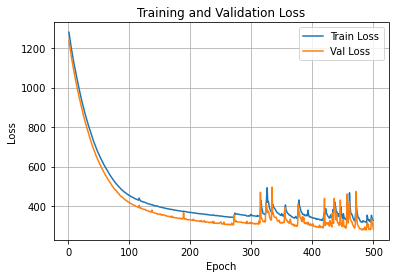

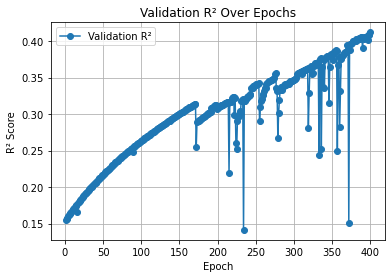

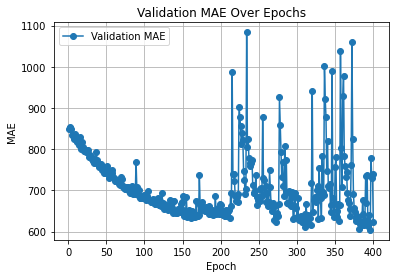

In [31]:
epochs = range(1, len(loss_over_epochs) + 1)

# Training and Validation Loss
plt.figure()
plt.plot(epochs, loss_over_epochs, label="Train Loss")
plt.plot(epochs, val_loss_over_epochs, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# R²
plt.figure()
plt.plot(range(1, len(val_r2_over_epochs) + 1), val_r2_over_epochs, marker='o', label="Validation R²")
plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.title("Validation R² Over Epochs")
plt.grid(True)
plt.legend()
plt.show()

# MAE
plt.figure()
plt.plot(range(1, len(val_mae_over_epochs) + 1), val_mae_over_epochs, marker='o', label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Validation MAE Over Epochs")
plt.grid(True)
plt.legend()
plt.show()
